In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy
import scipy.stats
import pywt
import os
from skimage.transform import rotate
from skimage.feature import local_binary_pattern
from skimage import io, color
from skimage.color import label2rgb
from skimage.util import img_as_ubyte
from numpy.fft import fft2, fftshift
from scipy.fftpack import dct
from PIL import Image

# LBP Features Examples

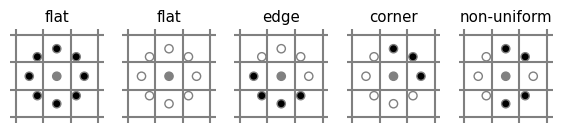

In [13]:
METHOD = 'uniform'
plt.rcParams['font.size'] = 9

def plot_circle(ax, center, radius, color):
    circle = plt.Circle(center, radius, facecolor=color, edgecolor='0.5')
    ax.add_patch(circle)

def plot_lbp_model(ax, binary_values):
    theta = np.deg2rad(45)
    R = 1
    r = 0.15
    w = 1.5
    gray = '0.5'

    plot_circle(ax, (0, 0), radius=r, color=gray)
    for i, facecolor in enumerate(binary_values):
        x = R * np.cos(i * theta)
        y = R * np.sin(i * theta)
        plot_circle(ax, (x, y), radius=r, color=str(facecolor))

    for x in np.linspace(-w, w, 4):
        ax.axvline(x, color=gray)
        ax.axhline(x, color=gray)

    ax.axis('image')
    ax.axis('off')
    size = w + 0.2
    ax.set_xlim(-size, size)
    ax.set_ylim(-size, size)

fig, axes = plt.subplots(ncols=5, figsize=(7,2))

titles = ['flat', 'flat', 'edge', 'corner', 'non-uniform']

binary_patterns = [
    np.zeros(8),
    np.ones(8),
    np.hstack([np.ones(4), np.zeros(4)]),
    np.hstack([np.zeros(3), np.ones(5)]),
    [1, 0, 0, 1, 1, 1, 0, 0],
]

for ax, values, name in zip(axes, binary_patterns, titles):
    plot_lbp_model(ax, values)
    ax.set_title(name)

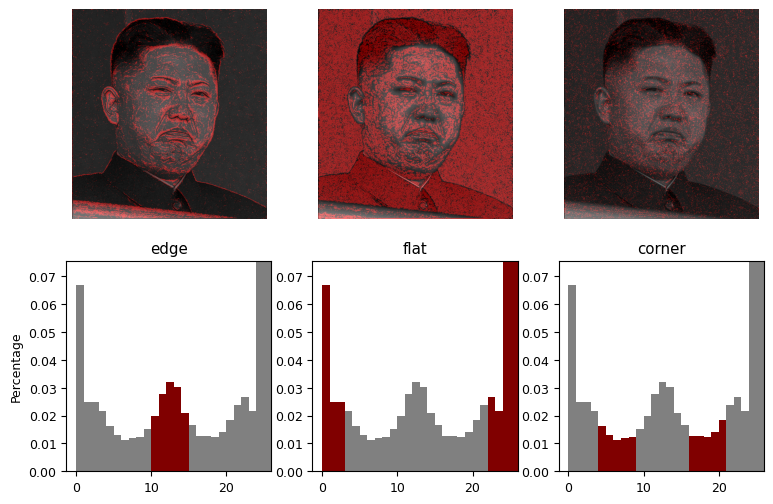

In [14]:
radius = 3
n_points = 8 * radius

def overlay_labels(image, lbp, labels):
    mask = np.logical_or.reduce([lbp == each for each in labels])
    return label2rgb(mask, image=image, bg_label=0, alpha=0.5)

def highlight_bars(bars, indexes):
    for i in indexes:
        bars[i].set_facecolor('maroon')

image = io.imread('1a5x44_orig.jpg')
image = color.rgb2gray(image)
image = img_as_ubyte(image)
lbp = local_binary_pattern(image, n_points, radius, METHOD)

def hist(ax, lbp):
    n_bins = int(lbp.max() + 1)
    return ax.hist(
        lbp.ravel(), density=True, bins=n_bins, range=(0, n_bins), facecolor='0.5'
    )

fig, (ax_img, ax_hist) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))
plt.gray()

titles = ('edge', 'flat', 'corner')
w = width = radius - 1
edge_labels = range(n_points // 2 - w, n_points // 2 + w + 1)
flat_labels = list(range(0, w + 1)) + list(range(n_points - w, n_points + 2))
i_14 = n_points // 4
i_34 = 3 * (n_points // 4)
corner_labels = list(range(i_14 - w, i_14 + w + 1)) + list(
    range(i_34 - w, i_34 + w + 1)
)

label_sets = (edge_labels, flat_labels, corner_labels)

for ax, labels in zip(ax_img, label_sets):
    ax.imshow(overlay_labels(image, lbp, labels))

for ax, labels, name in zip(ax_hist, label_sets, titles):
    counts, _, bars = hist(ax, lbp)
    highlight_bars(bars, labels)
    ax.set_ylim(top=np.max(counts[:-1]))
    ax.set_xlim(right=n_points + 2)
    ax.set_title(name)

ax_hist[0].set_ylabel('Percentage')
for ax in ax_img:
    ax.axis('off')

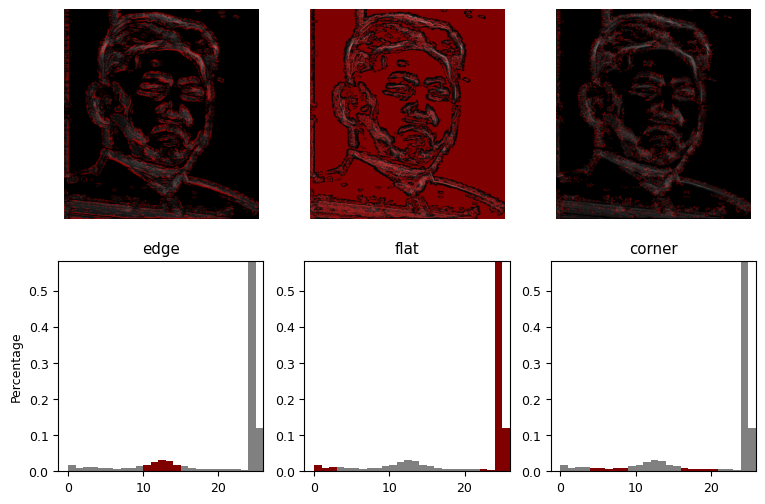

In [4]:
radius = 3
n_points = 8 * radius

def overlay_labels(image, lbp, labels):
    mask = np.logical_or.reduce([lbp == each for each in labels])
    return label2rgb(mask, image=image, bg_label=0, alpha=0.5)

def highlight_bars(bars, indexes):
    for i in indexes:
        bars[i].set_facecolor('maroon')

image = io.imread('1a5x44_orig_edged.png')
# image = color.rgb2gray(image)
# image = img_as_ubyte(image)
lbp = local_binary_pattern(image, n_points, radius, METHOD)

def hist(ax, lbp):
    n_bins = int(lbp.max() + 1)
    return ax.hist(
        lbp.ravel(), density=True, bins=n_bins, range=(0, n_bins), facecolor='0.5'
    )

fig, (ax_img, ax_hist) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))
plt.gray()

titles = ('edge', 'flat', 'corner')
w = width = radius - 1
edge_labels = range(n_points // 2 - w, n_points // 2 + w + 1)
flat_labels = list(range(0, w + 1)) + list(range(n_points - w, n_points + 2))
i_14 = n_points // 4
i_34 = 3 * (n_points // 4)
corner_labels = list(range(i_14 - w, i_14 + w + 1)) + list(
    range(i_34 - w, i_34 + w + 1)
)

label_sets = (edge_labels, flat_labels, corner_labels)

for ax, labels in zip(ax_img, label_sets):
    ax.imshow(overlay_labels(image, lbp, labels))

for ax, labels, name in zip(ax_hist, label_sets, titles):
    counts, _, bars = hist(ax, lbp)
    highlight_bars(bars, labels)
    ax.set_ylim(top=np.max(counts[:-1]))
    ax.set_xlim(right=n_points + 2)
    ax.set_title(name)

ax_hist[0].set_ylabel('Percentage')
for ax in ax_img:
    ax.axis('off')

# Assisting Functions

In [2]:
import json
from pathlib import Path
from typing import Dict, List

class IMD2020Indexer:
    IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

    def __init__(self, dataset_root: str):
        self.dataset_root = Path(dataset_root)
        self.index: Dict[str, Dict] = {}

    def build_index(self) -> Dict:
        """
        Main function to build dataset index.
        """
        if not self.dataset_root.exists():
            raise FileNotFoundError(f'Dataset root not found: {self.dataset_root}')

        for folder in sorted(self.dataset_root.iterdir()):
            if folder.is_dir():
                folder_data = self._process_folder(folder)
                # print(folder_data)
                if folder_data['original'] is not None and len(folder_data['manipulated']) > 0:
                    self.index[folder.name] = folder_data

        return self.index

    def save_to_json(self, output_path: str):
        """
        Save index to JSON file.
        """
        with open(output_path, 'w') as f:
            json.dump(self.index, f, indent=4)

    def load_from_json(self, json_path: str):
        """
        Load previously saved index.
        """
        with open(json_path, 'r') as f:
            self.index = json.load(f)

        return self.index

    def _process_folder(self, folder_path: Path) -> Dict:
        """
        Process a single IMD2020 folder.
        """
        folder_dict = {
            'original': None,
            'manipulated': []
        }

        files = list(folder_path.glob('*'))

        for file in files:
            stem = file.stem

            if stem.endswith('_orig'):
                folder_dict['original'] = str(file)

        for file in files:
            stem = file.stem # File name

            if stem.endswith('_orig'):
                continue

            if stem.endswith('_mask'):
                continue

            parts = stem.split('_')
            if len(parts) >= 2 and parts[-1].isdigit():
                base_name = stem
                mask_name = f'{base_name}_mask'

                mask_path = None
                for candidate in files:
                    if candidate.stem == mask_name:
                        mask_path = str(candidate)
                        break

                folder_dict['manipulated'].append({
                    'image': str(file),
                    'mask': mask_path
                })

        return folder_dict

In [3]:
dataset_path = 'C:/Users/Public/Downloads/IMD2020_edge_mapped'
indexer = IMD2020Indexer(dataset_path)
index_dict = indexer.build_index()
indexer.save_to_json('imd2020_index.json')

In [3]:
image = io.imread('data/samples/c8ufr4g_0_edged.png')

def dsIndex2Features(
    dataset_index,
    feature_extractors,
    patch_size=16,
    stride=8,
    mask_threshold=0.1
):
    X = []
    Y = []
    
    for key, path in dataset_index.items():
        print('Processing: ', key)
        
        orig_img = io.imread(path['original'])

        orig_feature_list = []
        for extractor in feature_extractors:
            
            if not callable(extractor):
                raise NameError(
                    f"Extractor '{extractor}' is not a valid function. "
                    f"Try using extractors in this list: {feature_extractors}")
            
            feat = extractor(orig_img, patch_size, stride)
            orig_feature_list.append(feat)
            
        orig_features = np.hstack(orig_feature_list)
        orig_labels = np.zeros(orig_features.shape[0], dtype=np.uint8)

        X.append(orig_features)
        Y.append(orig_labels)

        for sample in path['manipulated']:
            manip_img = io.imread(sample['image'])

            manip_feature_list = []
            for extractor in feature_extractors:
            
                if not callable(extractor):
                    raise NameError(
                        f"Extractor '{extractor}' is not a valid function. "
                        f"Try using extractors in this list: {feature_extractors}")
            
                feat = extractor(manip_img, patch_size, stride)
                manip_feature_list.append(feat)
            
            manip_features = np.hstack(manip_feature_list)
            
            mask_img = io.imread(sample['mask'])
            mask_img = convert2gray(mask_img, binary=True)
            h, w = mask_img.shape
            mask_img, h, w = resize4patch(mask_img, h, w, patch_size)

            manip_labels = mask2labels(
                mask_img, mask_threshold, patch_size, stride
            )

            if len(manip_labels) != manip_features.shape[0]:
                raise ValueError('Patch count mismatch between features and mask')
            
            X.append(manip_features)
            Y.append(manip_labels)

    # X = np.vstack(X)
    # Y = np.concatenate(Y)

    return X, Y

# Turn a mask into a vector of labels of each patch
def mask2labels(
    mask_img,
    mask_threshold=0.1,
    patch_size=16,
    stride=8
):
    labels = []
    h, w = mask_img.shape
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = mask_img[y:y+patch_size, x:x+patch_size]

            isManip = (
                np.sum(patch) > mask_threshold * patch.size
            ).astype(np.uint8)
            labels.append(isManip)
            
    labels = np.array(labels, dtype=np.uint8)
    
    return labels

def convert2gray(image, binary=False):
    if len(image.shape) == 3:
        if image.shape[2] == 4: # RBGA -> Remove Alpha channel
            image = image[:, :, :3]
        image = color.rgb2gray(image)
        image = img_as_ubyte(image)

    if binary:
        image = (image>0).astype(np.uint8)
    return image

# Resize image for patch extracting
def resize4patch(image, h, w, patch_size=16):
    h = (h // patch_size) * patch_size
    w = (w // patch_size) * patch_size

    image = cv2.resize(
        image,
        (w, h),
        # Controls how pixel values are calculated when the image is scaled up or down.
        interpolation=cv2.INTER_AREA,
    )
    return image, h, w

def computeNoiseRes(image, blur_kernel):
    blurred = cv2.GaussianBlur(image, (blur_kernel, blur_kernel), 0)
    residual = image - blurred
    residual = cv2.normalize(residual, None, 0, 255, cv2.NORM_MINMAX)
    return residual

In [11]:
dataset_path = 'C:/Users/Public/Downloads/IMD2020_edge_mapped'
indexer = IMD2020Indexer(dataset_path)
index_dict = indexer.load_from_json('imd2020_index.json')
sample_index_dict = dict(list(index_dict.items())[:3])

feature_extractors = [
    extract_noise_residual_patches,
    extract_wavelet_patches,
    extract_fft_patches,
    # extract_dct_patches,
    extract_lbp_patches,
    # GLCM
    # Basic statistics
]

X, Y = dsIndex2Features(sample_index_dict, feature_extractors)
len(X), len(Y)

Processing:  1a07yi
Processing:  1a16mu
Processing:  1a1ogs


(7, 7)

In [47]:
print('Total features:', len(X[0][0]))

Total features: 82


# Local Binary Pattern Features Extraction

In [6]:
def extract_lbp_patches(
    image,
    patch_size=16,
    stride=8,
    P=8,
    R=3,
    multi_radi=True,
    method='uniform',
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)

    if method == 'uniform':
        n_bins = P + 2
    else:
        n_bins = 2 ** P

    features = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = image[y:y+patch_size, x:x+patch_size]

            if not multi_radi:
                lbp = local_binary_pattern(patch, P=P, R=R, method=method)
                
                hist, _ = np.histogram(
                    lbp.ravel(), # Continuous flattened array
                    bins=n_bins,
                    range=(0, n_bins)
                )

                # Normalize
                hist = hist.astype('float')
                hist /= (hist.sum() + 1e-7)

                features.append(hist)
            else:
                patch_features = []
                for r in range(1, 4):
                    lbp = local_binary_pattern(
                        patch,
                        P=P,
                        R=r,
                        method=method
                    )

                    hist, _ = np.histogram(
                        lbp.ravel(),
                        bins=n_bins,
                        range=(0, n_bins)
                    )

                    # Normalize
                    hist = hist.astype('float')
                    hist /= (hist.sum() + 1e-8)

                    patch_features.extend(hist)
                    
                features.append(np.array(patch_features))

    feature_matrix = np.array(features)

    return feature_matrix

In [28]:
lbp_feature_m = extract_lbp_patches(image, multi_radi=True)
lbp_feature_m.shape

(5767, 30)

# Noise Residual Features Extraction

In [7]:
def extract_noise_residual_patches(
    image,
    patch_size=16,
    stride=8,
    blur_kernel=5
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)
    residual = computeNoiseRes(image, blur_kernel)

    features = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = residual[y:y+patch_size, x:x+patch_size]

            hist, _ = np.histogram(
                patch.ravel(),
                bins=32,
                range=(0, 255),
            )
            mean = np.mean(patch)
            std = np.std(patch)
            skew = scipy.stats.skew(patch.ravel())
            kurt = scipy.stats.kurtosis(patch.ravel())

            # Normalize
            hist = hist.astype('float')
            hist /= (hist.sum() + 1e-7)

            feature_vector = np.concatenate([hist, [mean, std, skew, kurt]])
            features.append(feature_vector)

    feature_matrix = np.array(features)

    return feature_matrix

In [171]:
noiseRes_feature_m = extract_noise_residual_patches(image)
noiseRes_feature_m.shape

(5767, 36)

# Frequency-based Features Extraction

## Fast Fourier Transform Frequency Features Extraction

In [8]:
def extract_fft_patches(
    image,
    patch_size=16,
    stride=8,
    use_residual=False,
    blur_kernel=5
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)
    if use_residual:
        residual = computeNoiseRes(image, blur_kernel)

    features = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            
            if use_residual:
                patch = residual[y:y+patch_size, x:x+patch_size]
            else:
                patch = image[y:y+patch_size, x:x+patch_size]

            # Compute FFT
            F = fft2(patch)
            F = fftshift(F)
            magnitude = np.abs(F)

            # Power spectrum
            power = magnitude ** 2

            # Create frequency radius grid
            cy, cx = patch_size // 2, patch_size // 2
            y_grid, x_grid = np.ogrid[:patch_size, :patch_size]
            radius = np.sqrt((y_grid - cy)**2 + (x_grid - cx)**2)

            r_max = radius.max()

            # Frequency bands
            low = power[radius < r_max/3]
            mid = power[(radius >= r_max/3) & (radius < 2*r_max/3)]
            high = power[radius >= 2*r_max/3]

            low_energy = low.sum()
            mid_energy = mid.sum()
            high_energy = high.sum()

            # Normalize energies
            total_energy = low_energy + mid_energy + high_energy + 1e-8
            low_energy /= total_energy
            mid_energy /= total_energy
            high_energy /= total_energy

            # Spectral entropy
            p = power.ravel()
            p = p / (p.sum() + 1e-8)
            spectral_entropy = -np.sum(p * np.log2(p + 1e-8))

            feature_vector = np.array([
                low_energy,
                mid_energy,
                high_energy,
                spectral_entropy
            ])
            features.append(feature_vector)

    feature_matrix = np.array(features)
                       
    return feature_matrix

In [14]:
fft_feature_m = extract_fft_patches(image)
fft_feature_m.shape

(5767, 4)

## Wavelet High-Frequency Features Extraction

In [ ]:
def extract_wavelet_patches(
    image,
    patch_size=16,
    stride=8,
    wavelet='haar',
    use_residual=False,
    blur_kernel=5
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)
    if use_residual:
        residual = computeNoiseRes(image, blur_kernel)

    features = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            
            if use_residual:
                patch = residual[y:y+patch_size, x:x+patch_size]
            else:
                patch = image[y:y+patch_size, x:x+patch_size]

            coeffs2 = pywt.dwt2(patch, wavelet)
            LL, (LH, HL, HH) = coeffs2

            band_features = []
            for band in [LH, HL, HH]:
                mean = np.mean(band)
                std = np.std(band)
                energy = np.sum(band**2)
                kurt = scipy.stats.kurtosis(band.ravel())

                band_features.extend([mean, std, energy, kurt])
            features.append(np.array(band_features))

    feature_matrix = np.array(features)

    return feature_matrix

In [17]:
wt_feature_m = extract_wavelet_patches(image)
wt_feature_m.shape

(5767, 12)

## Discrete Cosine Transform Features Extraction (for ablation study)

In [ ]:
def extract_dct_patches(
    image,
    patch_size=16,
    stride=8,
    use_residual=False,
    blur_kernel=5
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)
    if use_residual:
        residual = computeNoiseRes(image, blur_kernel)

    features = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            
            if use_residual:
                patch = residual[y:y+patch_size, x:x+patch_size]
            else:
                patch = image[y:y+patch_size, x:x+patch_size]

            # Compute DCT
            D = dct(dct(patch.T, norm='ortho').T, norm='ortho')

            # Power spectrum
            power = D**2

            # Frequency zones
            low = power[:4, :4]
            mid = power[4:8, 4:8]
            high = power[8:, 8:]

            low_energy = low.sum()
            mid_energy = mid.sum()
            high_energy = high.sum()

            total = low_energy + mid_energy + high_energy + 1e-8

            # Normalize energies
            low_energy /= total
            mid_energy /= total
            high_energy /= total

            dc = np.abs(D[0, 0])
            ac_kurt = scipy.stats.kurtosis(D[1:, 1:].ravel())

            feature_vector = np.array([
                low_energy,
                mid_energy,
                high_energy,
                dc,
                ac_kurt
            ])
            features.append(feature_vector)

    feature_matrix = np.array(features)

    return feature_matrix

In [19]:
dct_feature_m = extract_dct_patches(image)
dct_feature_m.shape

(5767, 5)

In [18]:
from skimage.feature import graycomatrix, graycoprops

# GLCM
def extract_glcm_patches(
    image,
    patch_size=16,
    stride=8,
    use_residual=False,
    blur_kernel=5
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)
    if use_residual:
        residual = computeNoiseRes(image, blur_kernel)
    
    features=[]
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            
            if use_residual:
                patch = residual[y:y+patch_size, x:x+patch_size]
            else:
                patch = image[y:y+patch_size, x:x+patch_size]
                
            # Tính GLCM (khoảng cách là 1, gồm 4 hướng)
            glcm = graycomatrix(
                patch, 
                distances=[1], 
                angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                levels=256, 
                symmetric=True, 
                normed=True)
            
            # Trích xuất Contrast
            con = graycoprops(glcm, 'contrast').mean()
            # Trích xuất Correlation
            corre = graycoprops(glcm, 'correlation').mean()
            # Trích xuất Energy
            eng = graycoprops(glcm, 'energy').mean()
            # Trích xuất Homogeneity
            homo = graycoprops(glcm, 'homogeneity').mean()
            
            features.append([con, corre, eng, homo])
    feature_matrix = np.array(features)
        
    return feature_matrix

In [ ]:
image = io.imread("data/samples/1a5x44_orig.jpg")
glcm_feature = extract_glcm_patches(image)
glcm_feature.shape
# %time _= extract_glcm_patches(image)

CPU times: total: 17 s
Wall time: 18.2 s


In [5]:
from scipy.stats import kurtosis, skew

# Statistical Features
def extract_stat_patches(
    image,
    patch_size=16,
    stride=8
):
    image = convert2gray(image)
    h, w = image.shape
    image, h, w = resize4patch(image, h, w, patch_size)

    features = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = image[y:y+patch_size, x:x+patch_size]
            patch_1d = patch.flatten()
            
            # Kurtosis (Normal distribution có Kurtosis = 0)
            kurt_val = kurtosis(patch_1d, fisher=True)
            # Skewness
            skew_val = skew(patch_1d)            
            # Correlation
            if len(patch_1d) > 1:
                # Tương quan giữa pixel hiện tại và pixel kế tiếp
                corr = np.corrcoef(patch_1d[:-1], patch_1d[1:])[0, 1]
            else:
                corr = 0
            # Smoothness
            smooth = 1 - (1 / (1 + np.std(patch_1d)**2))
                
            features.append([kurt_val, skew_val, corr, smooth])            
    feature_matrix = np.array(features)
    
    return feature_matrix

In [6]:
#image = io.imread("C:/Users/DELL/Downloads/1a5x44_orig.jpg")
stat_feature = extract_stat_patches(image)
stat_feature.shape

(5767, 4)

# Tool for Features Assessment

In [ ]:
def featureAsseTool(feat_matrix, class_arr):
    i_1 = np.where(class_arr = 1)
    i_0 = np.where(class_arr = 0)
    